In [1]:
# Cell 1: Install libraries

!pip install -q geopandas dask[complete] xarray netCDF4 rasterio numba \
    matplotlib pandas numpy shapely pyogrio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00


In [2]:
# Cell 2: Import libraries

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import dask
import dask.dataframe as dd
import xarray as xr

from numba import jit
from shapely.geometry import Point

import time

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Cell 3: Load geospatial dataset

url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"

places = gpd.read_file(url)

print("Dataset loaded successfully!")
print("Number of records:", len(places))
print(places.head())

Dataset loaded successfully!
Number of records: 7342
   SCALERANK  NATSCALE  LABELRANK       FEATURECLA                    NAME  \
0         10         1        8.0  Admin-1 capital  Colonia del Sacramento   
1         10         1        8.0  Admin-1 capital                Trinidad   
2         10         1        8.0  Admin-1 capital             Fray Bentos   
3         10         1        8.0  Admin-1 capital               Canelones   
4         10         1        8.0  Admin-1 capital                 Florida   

  NAMEPAR NAMEALT               NAMEASCII  ADM0CAP CAPIN  ...  FCLASS_ID  \
0    None    None  Colonia del Sacramento        0  None  ...       None   
1    None    None                Trinidad        0  None  ...       None   
2    None    None             Fray Bentos        0  None  ...       None   
3    None    None               Canelones        0  None  ...       None   
4    None    None                 Florida        0  None  ...       None   

   FCLASS_PL FCLASS_G

In [4]:
# Cell 4: Basic dataset information

print("Columns:")
print(places.columns.tolist())

print("\nCoordinate Reference System:")
print(places.crs)

print("\nDataset shape:")
print(places.shape)

Columns:
['SCALERANK', 'NATSCALE', 'LABELRANK', 'FEATURECLA', 'NAME', 'NAMEPAR', 'NAMEALT', 'NAMEASCII', 'ADM0CAP', 'CAPIN', 'WORLDCITY', 'MEGACITY', 'SOV0NAME', 'SOV_A3', 'ADM0NAME', 'ADM0_A3', 'ADM1NAME', 'ISO_A2', 'NOTE', 'LATITUDE', 'LONGITUDE', 'POP_MAX', 'POP_MIN', 'POP_OTHER', 'RANK_MAX', 'RANK_MIN', 'MEGANAME', 'LS_NAME', 'MAX_POP10', 'MAX_POP20', 'MAX_POP50', 'MAX_POP300', 'MAX_POP310', 'MAX_NATSCA', 'MIN_AREAKM', 'MAX_AREAKM', 'MIN_AREAMI', 'MAX_AREAMI', 'MIN_PERKM', 'MAX_PERKM', 'MIN_PERMI', 'MAX_PERMI', 'MIN_BBXMIN', 'MAX_BBXMIN', 'MIN_BBXMAX', 'MAX_BBXMAX', 'MIN_BBYMIN', 'MAX_BBYMIN', 'MIN_BBYMAX', 'MAX_BBYMAX', 'MEAN_BBXC', 'MEAN_BBYC', 'TIMEZONE', 'UN_FID', 'POP1950', 'POP1955', 'POP1960', 'POP1965', 'POP1970', 'POP1975', 'POP1980', 'POP1985', 'POP1990', 'POP1995', 'POP2000', 'POP2005', 'POP2010', 'POP2015', 'POP2020', 'POP2025', 'POP2050', 'MIN_ZOOM', 'WIKIDATAID', 'WOF_ID', 'CAPALT', 'NAME_EN', 'NAME_DE', 'NAME_ES', 'NAME_FR', 'NAME_PT', 'NAME_RU', 'NAME_ZH', 'LABEL', 

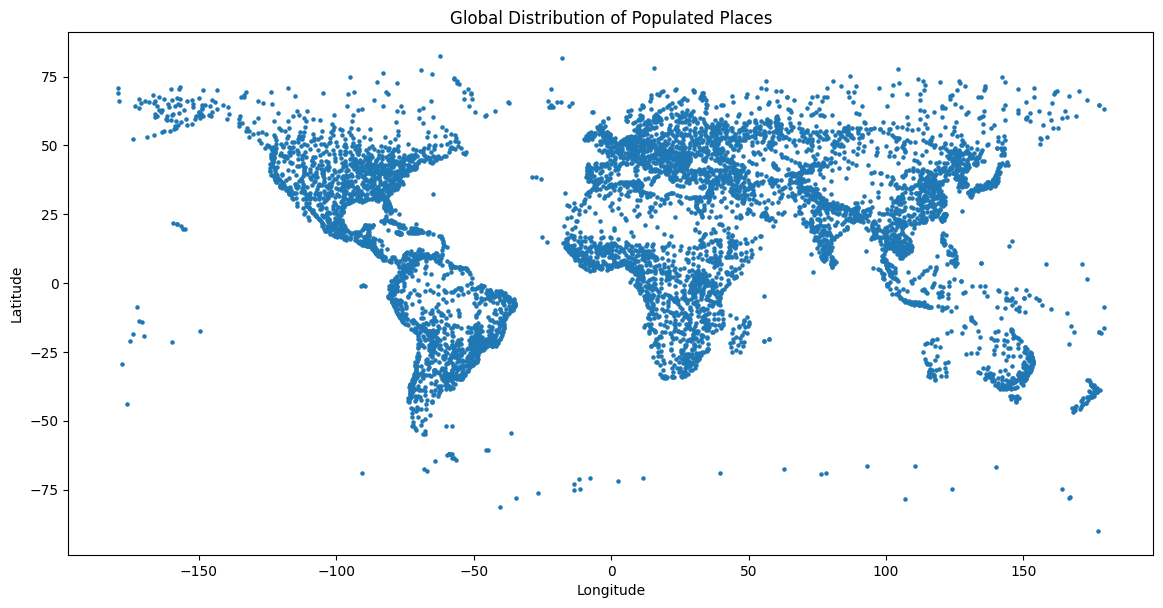

In [5]:
# Cell 5: Visualize populated places

fig, ax = plt.subplots(figsize=(14, 8))

places.plot(
    ax=ax,
    markersize=5
)

ax.set_title("Global Distribution of Populated Places")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [6]:
# Cell 6: Create simulated satellite bands

np.random.seed(42)

rows = 2000
cols = 2000

red_band = np.random.uniform(0.05, 0.6, (rows, cols)).astype(np.float32)
nir_band = np.random.uniform(0.2, 0.9, (rows, cols)).astype(np.float32)

print("Red band shape:", red_band.shape)
print("NIR band shape:", nir_band.shape)

Red band shape: (2000, 2000)
NIR band shape: (2000, 2000)


In [7]:
# Cell 7: Normal Python NDVI calculation

def calculate_ndvi_python(red, nir):
    result = np.zeros_like(red)

    for i in range(red.shape[0]):
        for j in range(red.shape[1]):

            denominator = nir[i, j] + red[i, j]

            if denominator != 0:
                result[i, j] = (
                    (nir[i, j] - red[i, j]) /
                    denominator
                )

    return result


start = time.time()

ndvi_python = calculate_ndvi_python(red_band, nir_band)

python_time = time.time() - start

print("Normal Python execution time:",
      round(python_time, 4), "seconds")

Normal Python execution time: 4.7374 seconds


In [8]:
# Cell 8: Numba optimized NDVI

@jit(nopython=True)
def calculate_ndvi_numba(red, nir):

    result = np.zeros_like(red)

    for i in range(red.shape[0]):
        for j in range(red.shape[1]):

            denominator = nir[i, j] + red[i, j]

            if denominator != 0:
                result[i, j] = (
                    (nir[i, j] - red[i, j]) /
                    denominator
                )

    return result


# First execution includes compilation
ndvi_numba = calculate_ndvi_numba(red_band, nir_band)

# Measure optimized execution
start = time.time()

ndvi_numba = calculate_ndvi_numba(red_band, nir_band)

numba_time = time.time() - start

print("Numba execution time:",
      round(numba_time, 4), "seconds")

Numba execution time: 0.0136 seconds


In [9]:
# Cell 9: Performance comparison

print("Normal Python:", round(python_time, 4), "seconds")
print("Numba:", round(numba_time, 4), "seconds")

speedup = python_time / numba_time

print("Speedup:", round(speedup, 2), "x")

Normal Python: 4.7374 seconds
Numba: 0.0136 seconds
Speedup: 348.26 x


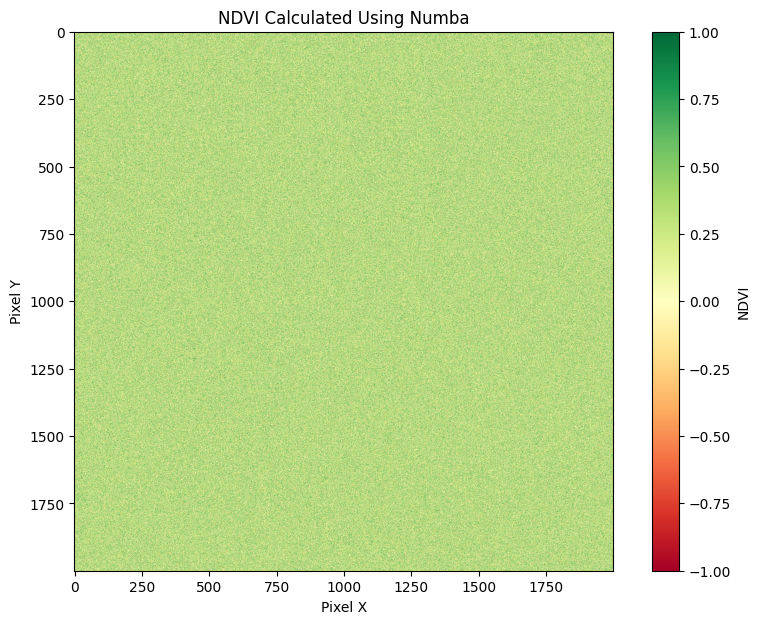

In [10]:
# Cell 10: Visualize NDVI

plt.figure(figsize=(10, 7))

plt.imshow(
    ndvi_numba,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDVI")

plt.title("NDVI Calculated Using Numba")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")

plt.show()

In [11]:
# Cell 11: Create a larger dataset for Dask

# Duplicate the populated places dataset
large_places = pd.concat(
    [places] * 20,
    ignore_index=True
)

large_places = gpd.GeoDataFrame(
    large_places,
    geometry="geometry",
    crs=places.crs
)

print("Large dataset size:", len(large_places))

Large dataset size: 146840


In [12]:
# Cell 12: GeoPandas buffer operation

# Use a projected CRS for distance-based buffering
places_projected = large_places.to_crs(epsg=3857)

start = time.time()

buffered_gdf = places_projected.copy()

buffered_gdf["buffer"] = buffered_gdf.geometry.buffer(5000)

geopandas_time = time.time() - start

print(
    "GeoPandas buffer time:",
    round(geopandas_time, 4),
    "seconds"
)

GeoPandas buffer time: 4.2528 seconds


In [13]:
# Cell 13: Dask processing

# Create a normal pandas dataframe containing coordinates
dask_df = pd.DataFrame({
    "longitude": large_places.geometry.x.values,
    "latitude": large_places.geometry.y.values
})

# Convert to Dask DataFrame
ddf = dd.from_pandas(
    dask_df,
    npartitions=8
)

print(ddf)

Dask DataFrame Structure:
              longitude latitude
npartitions=8                   
0               float64  float64
18355               ...      ...
...                 ...      ...
128485              ...      ...
146839              ...      ...
Dask Name: frompandas, 1 expression
Expr=df


In [14]:
# Cell 14: Dask parallel calculation

def calculate_distance(df):

    df = df.copy()

    df["distance_from_origin"] = np.sqrt(
        df["longitude"] ** 2 +
        df["latitude"] ** 2
    )

    return df


start = time.time()

result_dask = ddf.map_partitions(
    calculate_distance,
    meta={
        "longitude": "f8",
        "latitude": "f8",
        "distance_from_origin": "f8"
    }
)

result_dask = result_dask.compute()

dask_time = time.time() - start

print(
    "Dask execution time:",
    round(dask_time, 4),
    "seconds"
)

print(result_dask.head())

Dask execution time: 0.3189 seconds
   longitude   latitude  distance_from_origin
0 -57.836116 -34.469788             67.328913
1 -56.900997 -33.543999             66.052428
2 -58.303998 -33.138999             67.063771
3 -56.284002 -34.538004             66.036070
4 -56.214998 -34.099002             65.748521


In [15]:
# Cell 15: Create climate dataset

time_values = pd.date_range(
    "2015-01-01",
    "2024-12-01",
    freq="MS"
)

latitudes = np.linspace(-90, 90, 180)
longitudes = np.linspace(-180, 180, 360)

temperature = np.random.normal(
    loc=20,
    scale=8,
    size=(
        len(time_values),
        len(latitudes),
        len(longitudes)
    )
).astype(np.float32)

print("Climate data shape:", temperature.shape)

Climate data shape: (120, 180, 360)


In [16]:
# Cell 16: Create xarray + Dask dataset

climate = xr.DataArray(
    temperature,
    dims=["time", "latitude", "longitude"],
    coords={
        "time": time_values,
        "latitude": latitudes,
        "longitude": longitudes
    },
    name="temperature"
)

# Convert to Dask-backed array
climate_dask = climate.chunk({
    "time": 12,
    "latitude": 60,
    "longitude": 120
})

print(climate_dask)

<xarray.DataArray 'temperature' (time: 120, latitude: 180, longitude: 360)> Size: 31MB
dask.array<xarray-<this-array>, shape=(120, 180, 360), dtype=float32, chunksize=(12, 60, 120), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 960B 2015-01-01 2015-02-01 ... 2024-12-01
  * latitude   (latitude) float64 1kB -90.0 -88.99 -87.99 ... 87.99 88.99 90.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0


In [17]:
# Cell 17: Yearly temperature analysis

start = time.time()

yearly_temperature = (
    climate_dask
    .groupby("time.year")
    .mean()
    .compute()
)

xarray_time = time.time() - start

print(
    "xarray + Dask execution time:",
    round(xarray_time, 4),
    "seconds"
)

print(yearly_temperature)

xarray + Dask execution time: 0.771 seconds
<xarray.DataArray 'temperature' (year: 10, latitude: 180, longitude: 360)> Size: 3MB
array([[[19.545359, 22.808756, 19.550138, ..., 23.87961 , 21.408728,
         22.372948],
        [15.281726, 20.667181, 18.39113 , ..., 20.174757, 21.239769,
         20.63743 ],
        [19.532246, 22.322546, 20.902184, ..., 21.755186, 16.434456,
         22.901955],
        ...,
        [19.205065, 18.352322, 19.830435, ..., 22.06996 , 24.459127,
         22.689367],
        [20.745905, 15.356849, 17.93086 , ..., 19.784882, 18.962906,
         18.715176],
        [19.393927, 16.319895, 19.648287, ..., 19.66129 , 20.784863,
         22.300049]],

       [[20.17004 , 21.715513, 23.74878 , ..., 21.352747, 24.451088,
         18.266077],
        [17.695433, 19.967329, 21.783213, ..., 21.09835 , 17.508821,
         18.03516 ],
        [21.082266, 20.754791, 19.895266, ..., 18.295662, 19.025864,
         17.958174],
...
        [15.811909, 21.322868, 22.063932, 

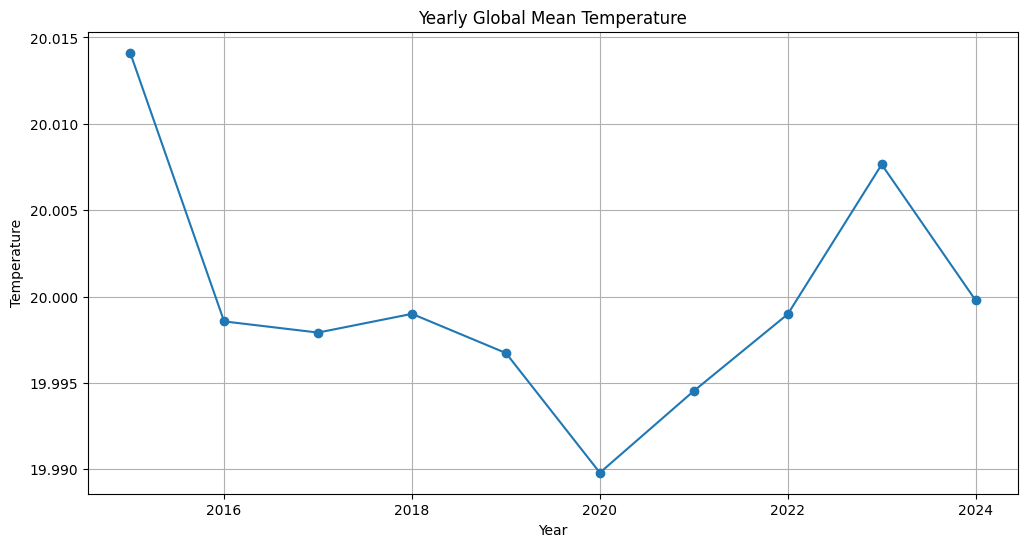

In [18]:
# Cell 18: Plot yearly average temperature

global_mean = yearly_temperature.mean(
    dim=["latitude", "longitude"]
)

plt.figure(figsize=(12, 6))

plt.plot(
    global_mean.year,
    global_mean.values,
    marker="o"
)

plt.title("Yearly Global Mean Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature")

plt.grid(True)

plt.show()

In [19]:
# Cell 19: Calculate spatial mean

spatial_mean = climate_dask.mean(
    dim=["latitude", "longitude"]
).compute()

print("Spatial mean calculated successfully!")

print(spatial_mean)

Spatial mean calculated successfully!
<xarray.DataArray 'temperature' (time: 120)> Size: 480B
array([19.997662, 20.033495, 19.980097, 20.046955, 20.005   , 20.002087,
       20.002413, 20.038029, 19.990793, 20.016712, 20.034332, 20.021812,
       20.010765, 19.955177, 19.978083, 20.002584, 20.005934, 19.976046,
       20.02366 , 20.01849 , 20.00935 , 19.979752, 20.019308, 20.003542,
       20.027552, 19.986616, 20.000635, 19.980896, 19.982855, 19.933987,
       19.972574, 20.066605, 19.99417 , 19.991093, 20.051104, 19.98688 ,
       20.040255, 19.960688, 20.002157, 20.043726, 19.991821, 20.007174,
       20.016424, 20.023115, 19.959476, 19.966875, 19.922993, 20.053267,
       19.98387 , 19.99977 , 19.993793, 20.000092, 19.995434, 20.029072,
       20.022165, 19.989302, 19.98579 , 20.002508, 19.971731, 19.987171,
       19.926249, 20.01191 , 19.971878, 19.96296 , 20.020525, 20.017178,
       20.006645, 20.0181  , 19.952543, 19.998955, 19.996876, 19.993723,
       19.933538, 19.985579, 1

In [20]:
# Cell 20: Final performance comparison

comparison = pd.DataFrame({
    "Method": [
        "Normal Python NDVI",
        "Numba NDVI",
        "GeoPandas Buffer",
        "Dask Processing",
        "xarray + Dask"
    ],
    "Time_seconds": [
        python_time,
        numba_time,
        geopandas_time,
        dask_time,
        xarray_time
    ]
})

print(comparison)

               Method  Time_seconds
0  Normal Python NDVI      4.737416
1          Numba NDVI      0.013603
2    GeoPandas Buffer      4.252806
3     Dask Processing      0.318921
4       xarray + Dask      0.770974


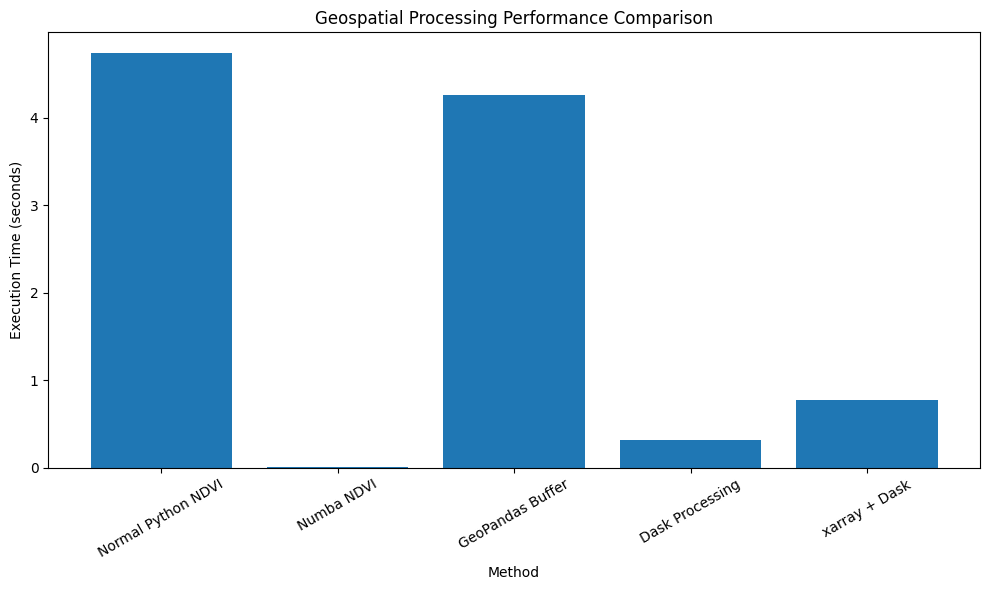

In [21]:
# Cell 21: Plot processing time comparison

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Method"],
    comparison["Time_seconds"]
)

plt.ylabel("Execution Time (seconds)")
plt.xlabel("Method")

plt.title("Geospatial Processing Performance Comparison")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [22]:
# Cell 22: Display final results

print("=" * 60)
print("GEO-SPATIAL DATA SCIENCE - EXPERIMENT 02")
print("=" * 60)

print("\n1. Dataset:")
print("   Natural Earth Populated Places")

print("\n2. Numba Optimization:")
print(f"   Python Time : {python_time:.4f} seconds")
print(f"   Numba Time  : {numba_time:.4f} seconds")
print(f"   Speedup     : {speedup:.2f}x")

print("\n3. Dask Processing:")
print(f"   Execution Time: {dask_time:.4f} seconds")

print("\n4. Climate Analysis:")
print(f"   xarray + Dask Time: {xarray_time:.4f} seconds")

print("\nExperiment completed successfully!")

GEO-SPATIAL DATA SCIENCE - EXPERIMENT 02

1. Dataset:
   Natural Earth Populated Places

2. Numba Optimization:
   Python Time : 4.7374 seconds
   Numba Time  : 0.0136 seconds
   Speedup     : 348.26x

3. Dask Processing:
   Execution Time: 0.3189 seconds

4. Climate Analysis:
   xarray + Dask Time: 0.7710 seconds

Experiment completed successfully!
